In [265]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv(r'C:\Users\anura\OneDrive\Desktop\ml\ML-Projects\Health Insurance\insurance.csv')

In [266]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [268]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [269]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [270]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [271]:
df.duplicated().sum()

np.int64(1)

In [272]:
df.drop_duplicates(inplace=True)

In [273]:
df.duplicated().sum()

np.int64(0)

In [274]:
df.shape

(1337, 7)

In [275]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

Text(0, 0.5, 'Frequency')

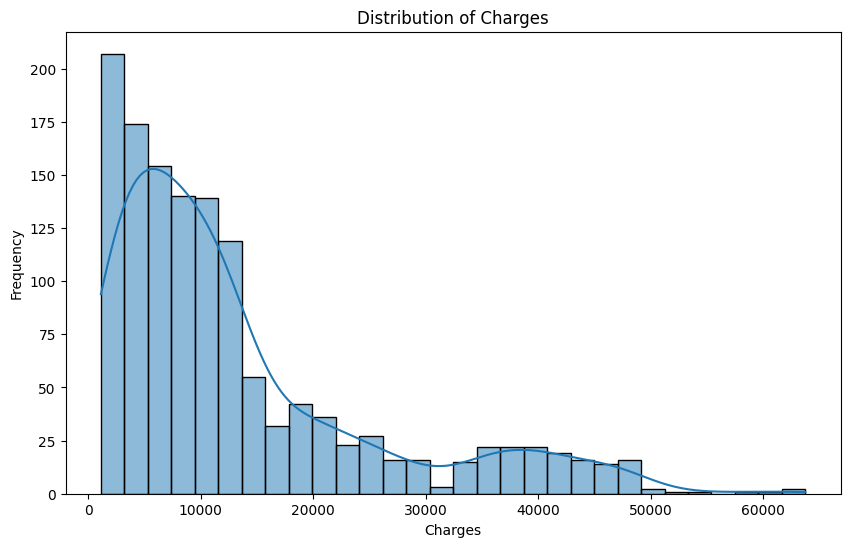

In [276]:
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')


### Distribution of Insurance Charges – Insights

- The distribution of insurance charges is **right-skewed**, indicating that most individuals have relatively lower medical expenses, while a smaller number incur very high costs.
- The presence of high-value cases suggests that factors such as **smoking, age, and BMI** may significantly influence insurance charges.
- Since the target variable is skewed, **tree-based models** are likely to perform well in capturing complex patterns in the data.


<Figure size 1000x600 with 0 Axes>

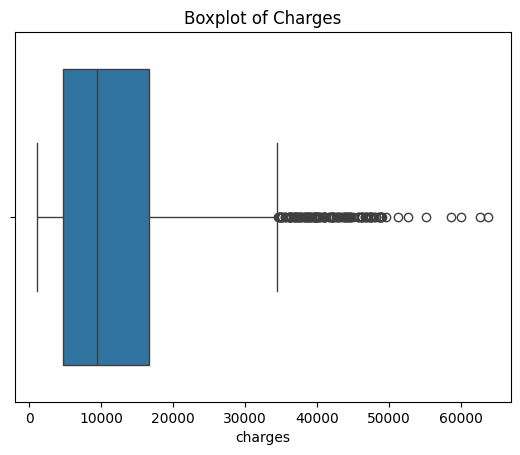

<Figure size 1000x600 with 0 Axes>

In [277]:
sns.boxplot(x=df['charges'])
plt.title('Boxplot of Charges')
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

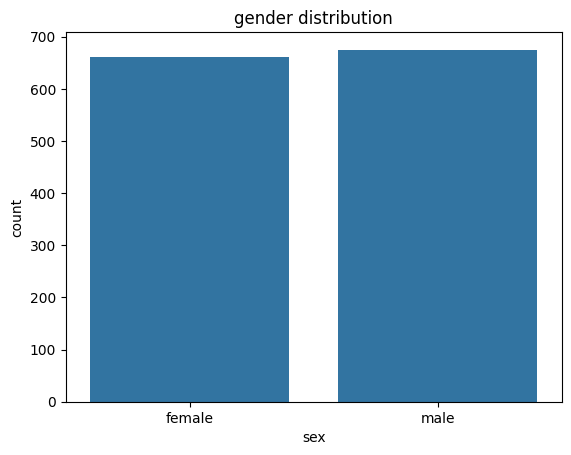

<Figure size 1000x600 with 0 Axes>

In [278]:
sns.countplot(x='sex', data=df)
plt.title('gender distribution')
plt.figure(figsize=(10,6))

### Gender Distribution – Insights

- The dataset shows a **nearly balanced distribution** between male and female individuals.
- Since both categories are well represented, the model is less likely to suffer from **gender-based data imbalance**.
- This balanced distribution helps in building a **fair and unbiased predictive model**.


<Figure size 1000x600 with 0 Axes>

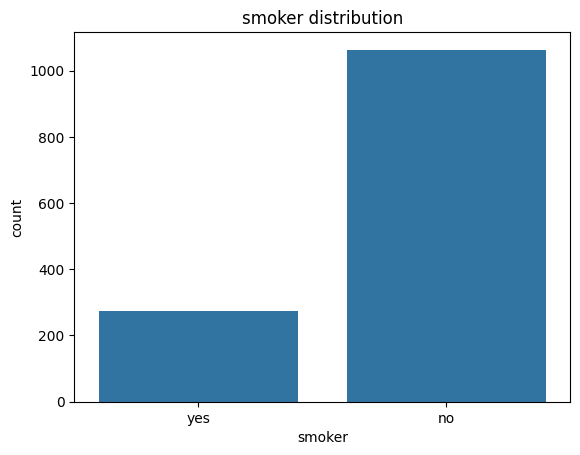

<Figure size 1000x600 with 0 Axes>

In [279]:
sns.countplot(x=df['smoker'])
plt.title('smoker distribution')    
plt.figure(figsize=(10,6))

### Smoker Distribution – Insights

- The dataset contains a **significantly higher number of non-smokers** compared to smokers.
- Although smokers represent a smaller portion of the data, smoking is known to have a **strong impact on medical insurance charges**, making it an important feature for prediction.
- The imbalance in smoker categories should be noted, but it does not pose a major issue for regression models.


Text(0.5, 1.0, 'region distribution')

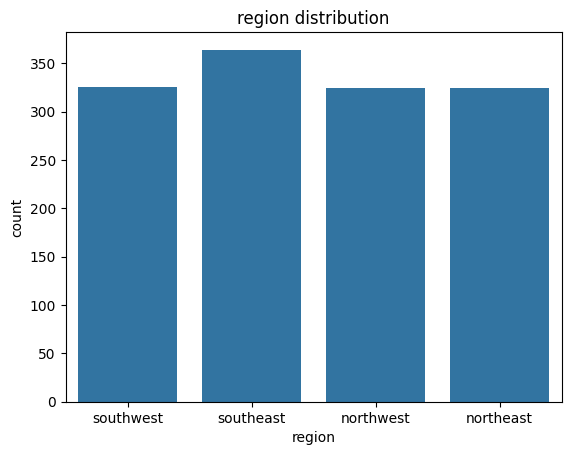

In [280]:
sns.countplot(x=df['region'])
plt.title('region distribution')

### Region Distribution – Insights

- The dataset shows a **fairly balanced distribution across all regions**, with no region dominating the data.
- This balanced representation ensures that the model can learn patterns without strong regional bias.
- Since the counts are similar, **region alone may not be a strong predictor** of insurance charges compared to factors like smoking, age, or BMI.


Text(0.5, 1.0, 'Age vs Charges')

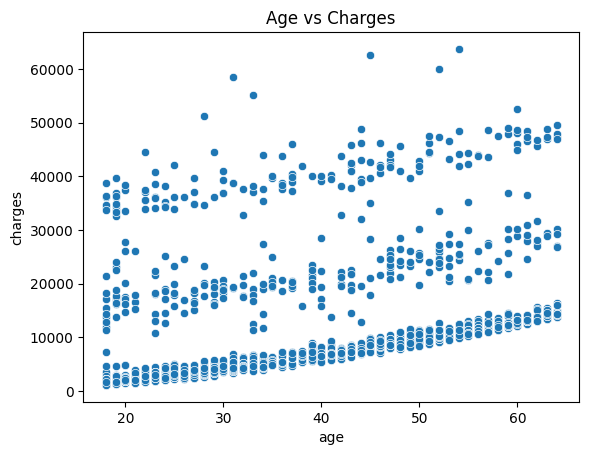

In [281]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Charges')

### Age vs Charges – Insights

- The scatter plot shows a **positive relationship** between age and insurance charges, indicating that medical costs generally increase as age increases.
- Younger individuals tend to have lower charges, while older individuals show a wider range of higher expenses.
- The variation in charges at similar ages suggests that **other factors such as smoking and BMI also significantly influence insurance costs**.


Text(0.5, 1.0, 'BMI vs Charges')

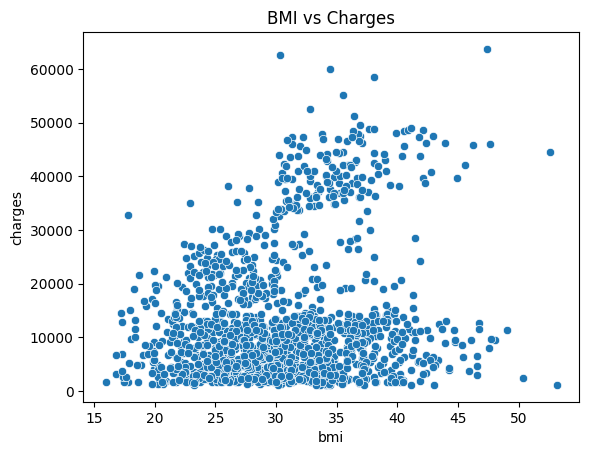

In [282]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Charges')

### BMI vs Charges – Insights

- The scatter plot indicates that **insurance charges tend to increase with higher BMI values**, especially beyond a BMI of around 30.
- Individuals with higher BMI show greater variability and generally higher medical expenses.
- The spread of points suggests that **BMI is an important factor influencing charges**, though other variables such as smoking and age also contribute significantly.


Text(0.5, 1.0, 'Charges by Region')

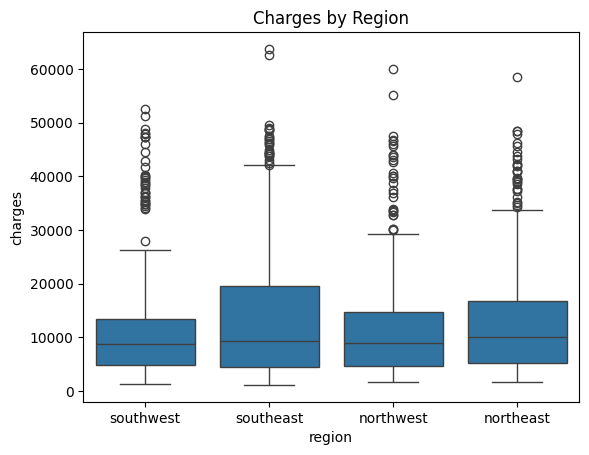

In [283]:
sns.boxplot(x=df['region'],y=df['charges'])
plt.title('Charges by Region')

### Region vs Charges – Insights

- Insurance charges appear to be **distributed similarly across all regions**, with comparable median values.
- While some regions show slightly higher variability, **no region shows a strong dominance in higher charges**.
- This suggests that **region is not a primary factor influencing insurance costs** compared to variables such as smoking status, age, or BMI.


Text(0.5, 1.0, 'Charges by Smoker Status')

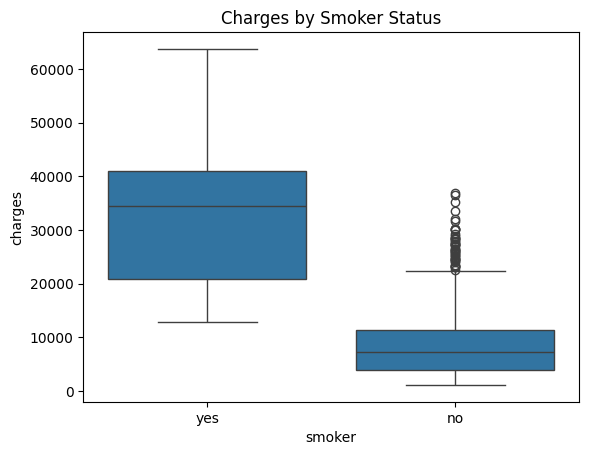

In [284]:
sns.boxplot(x=df['smoker'],y=df['charges'])
plt.title('Charges by Smoker Status')

### Smoker vs Charges – Insights

- The boxplot shows a **significant difference in insurance charges** between smokers and non-smokers.
- Smokers tend to have **substantially higher median and overall charges** compared to non-smokers.
- This indicates that **smoking is one of the most influential factors** affecting medical insurance costs and is likely to be an important feature in predictive modeling.


# ML Model


In [285]:
x=df.drop('charges', axis=1)
y=df['charges']

In [286]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pickle
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children'] 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])


In [287]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42
    )

In [288]:
from sklearn.neighbors import KNeighborsRegressor
knn_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
    
])
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)


In [289]:
from sklearn.linear_model import LinearRegression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [290]:
from sklearn.svm import SVR
svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR())
])
svr_pipeline.fit(X_train, y_train)
y_pred_svr = svr_pipeline.predict(X_test)

In [291]:
from sklearn.tree import DecisionTreeRegressor
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

In [292]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation matrix


In [293]:
def evaluate_model(y_test, y_pred, model_name):
    print(model_name)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-" * 40)


In [294]:
evaluate_model(y_test,y_pred_knn,"KNN Regression")
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test,y_pred_svr,"SVM regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

KNN Regression
MAE: 4494.192816041044
MSE: 65004149.37851739
RMSE: 8062.515077723414
R2 Score: 0.6462475961393122
----------------------------------------
Linear Regression
MAE: 4177.045561036326
MSE: 35478020.6752356
RMSE: 5956.342894363587
R2 Score: 0.8069287081198012
----------------------------------------
SVM regression
MAE: 9261.820813731363
MSE: 208257131.33082858
RMSE: 14431.11677351509
R2 Score: -0.13333474145511315
----------------------------------------
Decision Tree
MAE: 2804.8116326828363
MSE: 34953028.963362776
RMSE: 5912.108673169225
R2 Score: 0.8097857115858496
----------------------------------------
Random Forest
MAE: 2663.3287981399258
MSE: 22372575.46335238
RMSE: 4729.965693676052
R2 Score: 0.8782485052664795
----------------------------------------


`observatio`
- Random Forest achieved highest R² score and lowest RMSE, indicating better generalization compared to other models.

In [295]:
from sklearn.ensemble import RandomForestRegressor


from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(  
    n_estimators=200,      # more trees = better stability
    max_depth=20,          # control overfitting
    min_samples_split=5,   # better generalization
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1 ))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

evaluate_model(y_test, y_pred_rf, "Tuned Random Forest")


Tuned Random Forest
MAE: 2533.1081980251656
MSE: 20080058.984508798
RMSE: 4481.077881995447
R2 Score: 0.8907243737000285
----------------------------------------


## Hyperparameter Tuning Results (Random Forest)

To improve prediction performance, Random Forest hyperparameters such as **n_estimators**, **max_depth**, **min_samples_split**, and **min_samples_leaf** were tuned.

### Performance Comparison

| Metric | Before Tuning | After Tuning |
|--------|--------|--------|
| MAE | 2663.32 | 2533.10 |
| MSE | 222372575.46 | 20080058.98 |
| RMSE | 4729.96 | 4481.07 |
| R² Score | 0.8782 | 0.8907 |

### Observation

- Prediction error decreased after tuning.
- RMSE reduced, indicating better accuracy in medical cost estimation.
- R² score improved, meaning the model explains more variance in healthcare expenses.
- The tuned Random Forest model provides more reliable predictions compared to the default model.

### Conclusion

Hyperparameter tuning helped improve the Random Forest model’s performance and made it more suitable for **healthcare insurance cost prediction**.


In [296]:
with open("insurance_model_new.pkl", "wb") as f:
    pickle.dump(rf_pipeline, f)

print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this project, a **Machine Learning model** was developed to predict medical insurance charges using features such as age, BMI, children, smoking status, gender, and region.

### Work Done
- Data cleaning and preprocessing  
- Exploratory Data Analysis (EDA)  
- Encoding categorical variables  
- Training and evaluating multiple regression models  
- Saving the best model and building a Streamlit web app  

### Result
Among all models tested, the **Random Forest Regressor** performed the best, giving the highest accuracy and lowest error.

### Key Insights
- Smoking has a strong impact on insurance charges.  
- Charges generally increase with age and BMI.  
- Region has a smaller effect compared to other factors.

### Future Scope
- Hyperparameter tuning  
- More feature engineering  
- Using larger real-world datasets  

---

This project demonstrates an **end-to-end Machine Learning workflow**, from data analysis to model deployment.
